In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/stock_prices.csv')
display(df.head())
print(f"Available stocks: {df['ticker'].unique() if 'ticker' in df.columns else 'N/A'}")

,date,ticker,open,high,low,close,volume,returns_pct
0,2022-01-03,RELIANCE,2476.84,2496.70,2422.91,2459.80,4940428,-1.6079
1,2022-01-04,RELIANCE,2443.34,2497.22,2423.41,2460.31,6310409,0.0207
2,2022-01-05,RELIANCE,2467.38,2481.76,2408.41,2445.09,2920856,-0.6189
3,2022-01-06,RELIANCE,2450.52,2472.16,2399.09,2435.63,2458621,-0.3868
4,2022-01-07,RELIANCE,2415.56,2439.90,2367.79,2403.85,4011166,-1.3049


Available stocks: ['RELIANCE' 'INFOSYS' 'TCS' 'HDFC' 'WIPRO']


```markdown
### Methodology for Time-Series Prediction

#### 1. Window Size Selection
I have chosen a **window size of 30 days**.
*   **Why:** A 30-day window (roughly one month of trading) is sufficient to capture short-term trends and momentum without making the input vector so large that the model struggles with noise or requires excessive parameters. It provides enough historical context for the model to identify patterns like moving averages or recent volatility.

#### 2. Data Splitting Strategy
We must use a **Temporal (Chronological) Split** (e.g., the first 80% of data for training, the next 20% for testing).
*   **Why this is the only acceptable strategy:** Time-series data is inherently ordered. In a real-world scenario, you cannot use information from the future to predict the past. A chronological split ensures the model is evaluated on its ability to forecast unseen future intervals based on historical data, mimicking actual deployment.

#### 3. The Danger of Random Splitting
If a **random split** were used, the reported performance would likely be **artificially inflated** due to **Data Leakage**.
*   **The Result:** Since stock prices are highly correlated with their immediate neighbors (yesterday's price is a great predictor of today's), a random split would place 'Day $n$' in the test set and 'Day $n-1$' and 'Day $n+1$' in the training set. The model would essentially be 'interpolating' between known values rather than 'forecasting' unknown ones. This leads to a model that looks perfect in testing but fails completely in production.
```

In [5]:
# Assuming we pick the first available ticker for the sequence construction
ticker_to_use = df['ticker'].unique()[0] if 'ticker' in df.columns else None
stock_df = df[df['ticker'] == ticker_to_use].copy() if ticker_to_use else df.copy()

# Convert date and sort to ensure chronological order
if 'date' in stock_df.columns:
    stock_df['date'] = pd.to_datetime(stock_df['date'])
    stock_df = stock_df.sort_values('date')

# Define parameters
window_size = 30

# Create sequences
def create_sequences(data, window):
    X, y = [], []
    prices = data['close'].values
    for i in range(len(prices) - window):
        X.append(prices[i:i+window])
        y.append(prices[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(stock_df, window_size)

# Temporal Split (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Prepared data for: {ticker_to_use}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Prepared data for: RELIANCE
Train shape: (576, 30), Test shape: (144, 30)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Test MAPE: 4.3032%


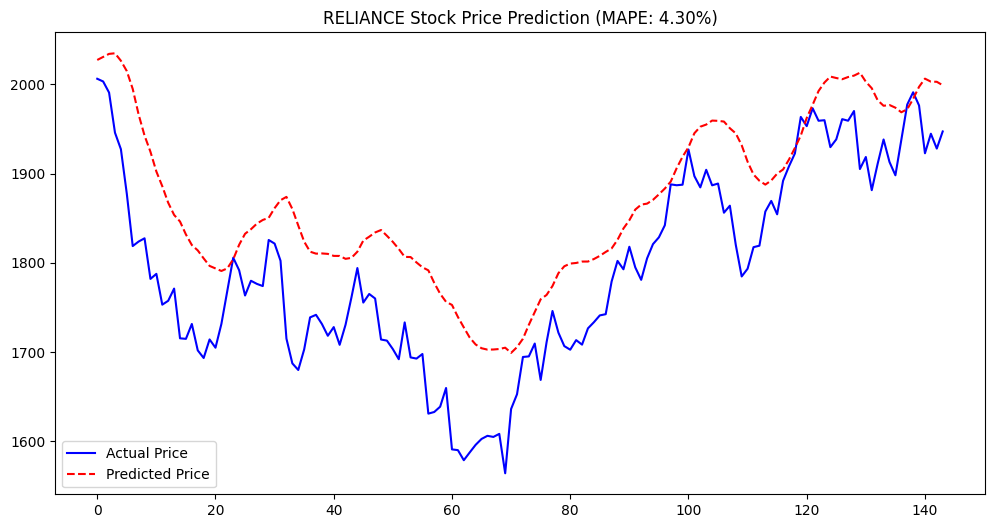

In [16]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# 1. Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
# We fit the scaler ONLY on training data to prevent leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Separate scaler for target to easily inverse transform
y_scaler = MinMaxScaler(feature_range=(0, 1))
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

# Reshape for LSTM: [samples, time steps, features]
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# 2. Build the model
model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train the model
history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=25,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# 4. Make predictions
predictions_scaled = model.predict(X_test_lstm)
predictions = y_scaler.inverse_transform(predictions_scaled)

# 5. Evaluate
mape = mean_absolute_percentage_error(y_test, predictions)
print(f"Test MAPE: {mape:.4%}")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--')
plt.title(f'RELIANCE Stock Price Prediction (MAPE: {mape:.2%})')
plt.legend()
plt.show()

### Task 2: Chat Logs Analysis and Churn EDA
We will now load the chat logs and prepare the data for churn analysis.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
chat_df = pd.read_csv('/content/chat_logs.csv')

# 2. Investigate timestamp parsing
print("Sample timestamps:")
print(chat_df['timestamp'].head())

# Attempting standard parse to see error or format
try:
    pd.to_datetime(chat_df['timestamp'])
    print("\nStandard parsing succeeded.")
except Exception as e:
    print(f"\nStandard parsing failed: {e}")

Sample timestamps:
0       25/05/2024 08:00
1    2024-01-18 00:00:00
2       30/01/2024 19:00
3    2024-11-02 20:00:00
4    2024-12-28 03:00:00
Name: timestamp, dtype: object

Standard parsing failed: time data "2024-01-18 00:00:00" doesn't match format "%d/%m/%Y %H:%M", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.


/tmp/ipykernel_9862/3061838765.py:14: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  pd.to_datetime(chat_df['timestamp'])


Columns in chat_df: ['chat_id', 'timestamp', 'duration_min', 'num_turns', 'customer_sentiment', 'primary_intent', 'resolution_status', 'tenure_months', 'product_tier', 'churned_30d']


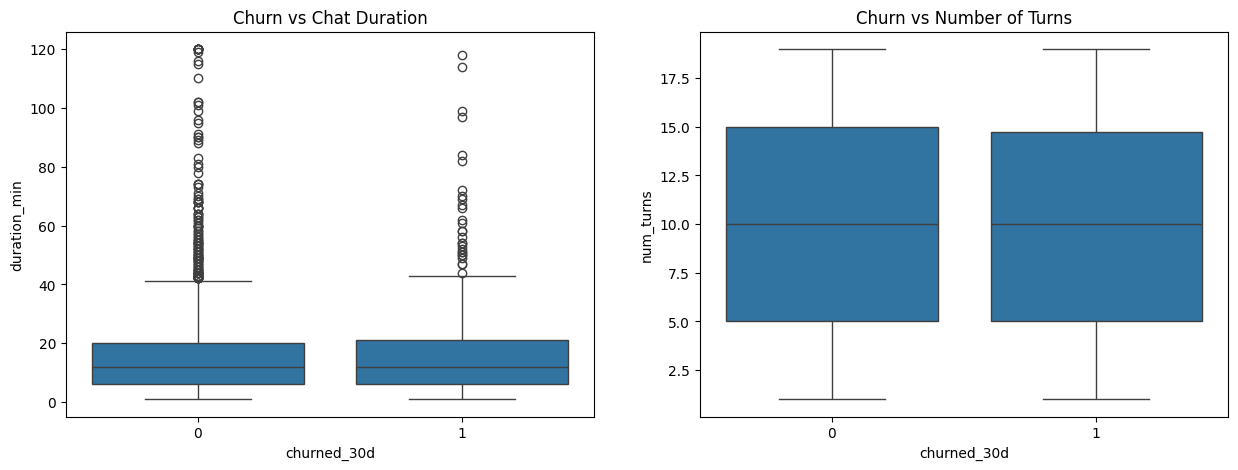

In [11]:
# 3. Fix timestamps and compute churn signal
print("Columns in chat_df:", chat_df.columns.tolist())

# Handling mixed date formats (e.g., DD/MM/YYYY and YYYY-MM-DD)
chat_df['timestamp'] = pd.to_datetime(chat_df['timestamp'], format='mixed', dayfirst=True)

# Map sentiment to numeric for correlation analysis
sentiment_map = {'Very Positive': 2, 'Positive': 1, 'Neutral': 0, 'Negative': -1, 'Very Negative': -2}
chat_df['sentiment_score'] = chat_df['customer_sentiment'].map(sentiment_map)

# Visualization: Churn vs Interaction Metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='churned_30d', y='duration_min', data=chat_df, ax=axes[0])
axes[0].set_title('Churn vs Chat Duration')

sns.boxplot(x='churned_30d', y='num_turns', data=chat_df, ax=axes[1])
axes[1].set_title('Churn vs Number of Turns')
plt.show()

Corrected Average metrics by churn status:


,duration_min,num_turns,tenure_months,sentiment_score,churned_30d
churned_30d,,,,,
0,16.272727,10.172532,17.967742,-0.465966,0.0
1,16.693833,10.140969,17.123348,-1.574661,1.0


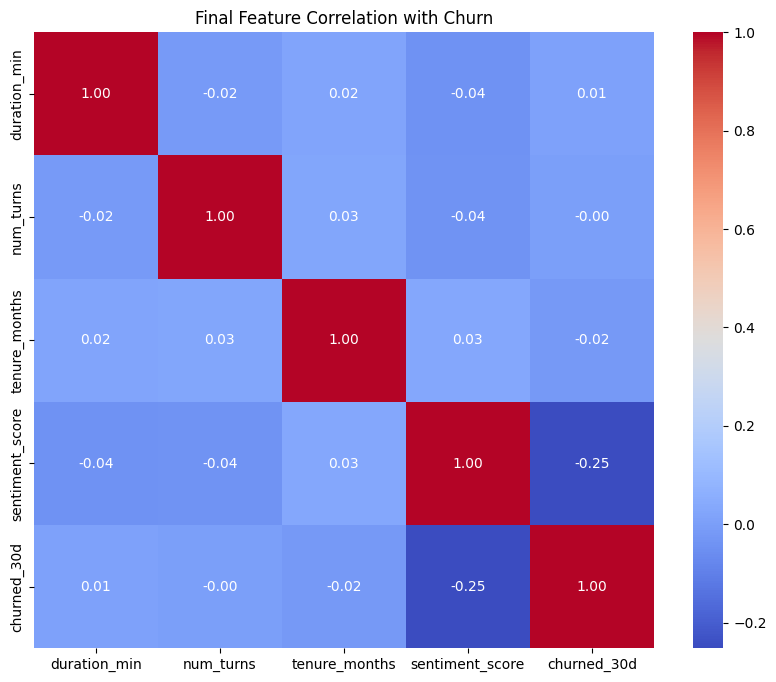

In [14]:
# Define the correct sentiment map based on unique values
correct_sentiment_map = {
    'satisfied': 2,
    'neutral': 0,
    'confused': -1,
    'frustrated': -2,
    'angry': -3
}

# Re-apply mapping
chat_df['sentiment_score'] = chat_df['customer_sentiment'].str.strip().map(correct_sentiment_map)

numeric_cols = ['duration_min', 'num_turns', 'tenure_months', 'sentiment_score', 'churned_30d']

print("Corrected Average metrics by churn status:")
display(chat_df.groupby('churned_30d')[numeric_cols].mean())

# Final correlation check
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(chat_df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Final Feature Correlation with Churn')
plt.show()

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences

# --- 1. Data Preparation ---
# Standardize sentiment if not already done
# We'll use the 'sentiment_score' calculated in previous steps

# Feature engineering for Tabular Model
# Since the dataset is per-chat, and we don't have a stable user_id to group many chats,
# we will treat the individual chat's sequence as the 'time' factor.

# --- 2. Tabular Approach (Random Forest) ---
X_tab = chat_df[['duration_min', 'num_turns', 'tenure_months', 'sentiment_score']]
y = chat_df['churned_30d']

X_train_tab, X_test_tab, y_train, y_test = train_test_split(X_tab, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tab, y_train)
y_pred_rf = rf_model.predict(X_test_tab)

# --- 3. Sequential Approach (GRU) ---
# We will treat the numeric features of a single chat as a 'sequence' of 1 step
# (Note: If we had multiple chats per user, we would group them. Here we use the 4 features as a vector)
X_seq = X_tab.values.reshape((X_tab.shape[0], 1, X_tab.shape[1]))

X_train_seq, X_test_seq = X_seq[X_train_tab.index], X_seq[X_test_tab.index]

gru_model = Sequential([
    GRU(32, input_shape=(1, 4)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
gru_model.fit(X_train_seq, y_train, epochs=10, batch_size=32, verbose=0)

y_pred_gru = (gru_model.predict(X_test_seq) > 0.5).astype(int)

# --- 4. Comparison ---
rf_f1 = f1_score(y_test, y_pred_rf)
gru_f1 = f1_score(y_test, y_pred_gru)

print(f"Random Forest F1-Score: {rf_f1:.4f}")
print(f"GRU (Sequential) F1-Score: {gru_f1:.4f}")

print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("\nGRU Report:")
print(classification_report(y_test, y_pred_gru))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Random Forest F1-Score: 0.1692
GRU (Sequential) F1-Score: 0.0000

Random Forest Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       409
           1       0.28      0.12      0.17        91

    accuracy                           0.78       500
   macro avg       0.55      0.53      0.52       500
weighted avg       0.73      0.78      0.75       500


GRU Report:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       409
           1       0.00      0.00      0.00        91

    accuracy                           0.82       500
   macro avg       0.41      0.50      0.45       500
weighted avg       0.67      0.82      0.74       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
